# $O(n^2)$

## 1. Import các thư viện

In [ ]:
import os
import sys
import json
import random
import importlib
import numpy as np
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath("../src"))

import utils as ut
importlib.reload(ut)
from utils import plot_execution_times, measure_algorithm_time, plot_comprehensive_barchart_grid, plot_danger_zone_heatmap, plot_algorithm_speedup_grid, calculate_baseline_n2, plot_baseline_n2

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

# Cấu hình tham số đồ thị
plt.rcParams['figure.figsize'] = (14, 10)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

## 2. Cài đặt thuật toán có độ phức tạp $O(n^2)$

Trong nhóm độ phức tạp $O(n^2)$, có nhiều thuật toán cơ bản như **Bubble Sort**, **Selection Sort** và **Insertion Sort**. Nhóm chọn **Selection Sort** và **Insertion Sort** làm hai đại diện chính, dựa trên các lý do sau:

* **Selection Sort đại diện cho nhóm có số phép so sánh gần như cố định:** Thuật toán luôn duyệt toàn bộ phần chưa sắp xếp để tìm phần tử nhỏ nhất, nên số phép so sánh gần như không phụ thuộc vào dữ liệu đầu vào. Điều này giúp phản ánh rõ bản chất $O(n^2)$ trên mọi phân bố dữ liệu.

* **Insertion Sort đại diện cho nhóm nhạy với cấu trúc dữ liệu:** Khi dữ liệu gần như đã sắp xếp, Insertion Sort hoạt động rất hiệu quả (gần $O(n)$). Ngược lại, với dữ liệu ngẫu nhiên hoặc sắp ngược, số phép dịch chuyển tăng mạnh và thời gian chạy tiến gần $O(n^2)$.

* **Tính đối lập rõ ràng để phân tích:** Hai thuật toán này tạo ra sự tương phản rõ rệt giữa một thuật toán “ổn định theo dữ liệu” (Selection Sort) và một thuật toán “nhạy với dữ liệu” (Insertion Sort), giúp đánh giá tác động của phân bố dữ liệu lên hiệu năng một cách trực quan nhất.

### 2.1 Selection Sort

In [2]:
def selection_sort(arr):
    n = len(arr)
    for i in range(n):
        min_idx = i
        for j in range(i + 1, n):
            if arr[j] < arr[min_idx]:
                min_idx = j
        arr[i], arr[min_idx] = arr[min_idx], arr[i]

### 2.2 Insertion Sort

In [3]:
def insertion_sort(arr):
    n = len(arr)
    for i in range(1, n):
        key = arr[i]
        j = i - 1

        while j >= 0 and arr[j] > key:
            arr[j + 1] = arr[j]
            j -= 1

        arr[j + 1] = key

## 3. Đọc dữ liệu từ file npz

In [4]:
sizes = [100, 1000, 10000, 100000]
datasets = ['random', 'nearly_sorted', 'many_duplicates', 'reverse_sorted']
base_path = '../data/' 

# Từ điển lưu trữ dữ liệu đã đọc: cấu trúc loaded_data['tên_dataset']['kích_thước']
loaded_data = {data_type: {} for data_type in datasets}

print("Đang tải dữ liệu lên bộ nhớ...")
for data_type in datasets:
    for size in sizes:
        folder_name = f'n_{size}'
        file_name = f'{data_type}_n{size}.npz'
        file_path = os.path.join(base_path, folder_name, file_name)
        
        try:
            npz_file = np.load(file_path)
            keys = npz_file.files
            # Lưu mảng dữ liệu vào từ điển
            loaded_data[data_type][size] = npz_file[keys[0]]
        except Exception as e:
            print(f"Lỗi với file {file_path}: {e}")
            loaded_data[data_type][size] = None

print("Đã tải xong toàn bộ dữ liệu!")

Đang tải dữ liệu lên bộ nhớ...
Đã tải xong toàn bộ dữ liệu!


## 4. Đo thời gian

#### Quy trình đo thời gian thực thi thuật toán

Nhóm $O(n^2)$ có thời gian chạy **tăng rất nhanh khi $n$ lớn**, vì vậy quy trình đo được thiết kế vừa đảm bảo độ tin cậy, vừa tránh tình trạng chạy quá lâu hoặc lỗi do quá tải.

##### 1. Giai đoạn chuẩn bị (Warm-up)
- Mỗi thuật toán được **chạy thử một lần** trên mảng dữ liệu gốc để ổn định cache và cơ chế nội bộ của Python.
- Lần chạy warm-up **không tính vào kết quả đo**.

##### 2. Giai đoạn đo lường
- Thuật toán chạy trên **4 loại phân bố dữ liệu**: ngẫu nhiên, gần như đã sắp, nhiều khóa trùng và sắp ngược.
- Với mỗi kích thước $n$, thuật toán chạy **nhiều lần** và lấy **Median** để giảm nhiễu hệ thống.
- **Lưu ý cho nhóm $O(n^2)$:** Do thời gian chạy tăng rất nhanh ở $n$ lớn, notebook này đặt `num_runs=1` để đảm bảo thời gian đo hợp lý. Khi cần độ ổn định cao hơn, có thể tăng `num_runs` ở các kích thước nhỏ.

##### 3. Quy tắc dữ liệu đầu vào
- Mỗi lần đo sử dụng **một bản copy mới** của mảng để đảm bảo thuật toán luôn chạy trên dữ liệu gốc, tránh sai lệch do mảng đã được sắp xếp trước đó.


### 4.1 Đo với thuật toán Selection Sort

In [5]:
print("Đang đo Selection Sort")
results_selection_sort = measure_algorithm_time(selection_sort, loaded_data, datasets, sizes, num_runs=1)

Đang đo Selection Sort


### 4.2 Đo với thuật toán Insertion Sort

In [6]:
print("Đang đo Insertion Sort")
results_insertion_sort = measure_algorithm_time(insertion_sort, loaded_data, datasets, sizes, num_runs=1)

Đang đo Insertion Sort


### Ghi nhận kết quả thực thi

In [ ]:
dir_path = "../results"
os.makedirs(dir_path, exist_ok=True)

with open(f"{dir_path}/selection_sort.json", "w") as f:
    json.dump(results_selection_sort, f)

with open(f"{dir_path}/insertion_sort.json", "w") as f:
    json.dump(results_insertion_sort, f)
    
print("Đã lưu kết quả O(n^2) thành công!")

Đã lưu kết quả O(n^2) thành công!


### Nạp kết quả đã lưu để vẽ biểu đồ

Các biểu đồ bên dưới sử dụng dữ liệu từ file JSON đã lưu sẵn để tránh thời gian chạy quá dài khi đo trực tiếp nhóm $O(n^2)$.

In [2]:
results_dir = "../results"

with open(os.path.join(results_dir, "selection_sort.json"), "r") as f:
    results_selection_sort = json.load(f)

with open(os.path.join(results_dir, "insertion_sort.json"), "r") as f:
    results_insertion_sort = json.load(f)

## 5. Biểu đồ trực quan

### 5.1 Selection Sort

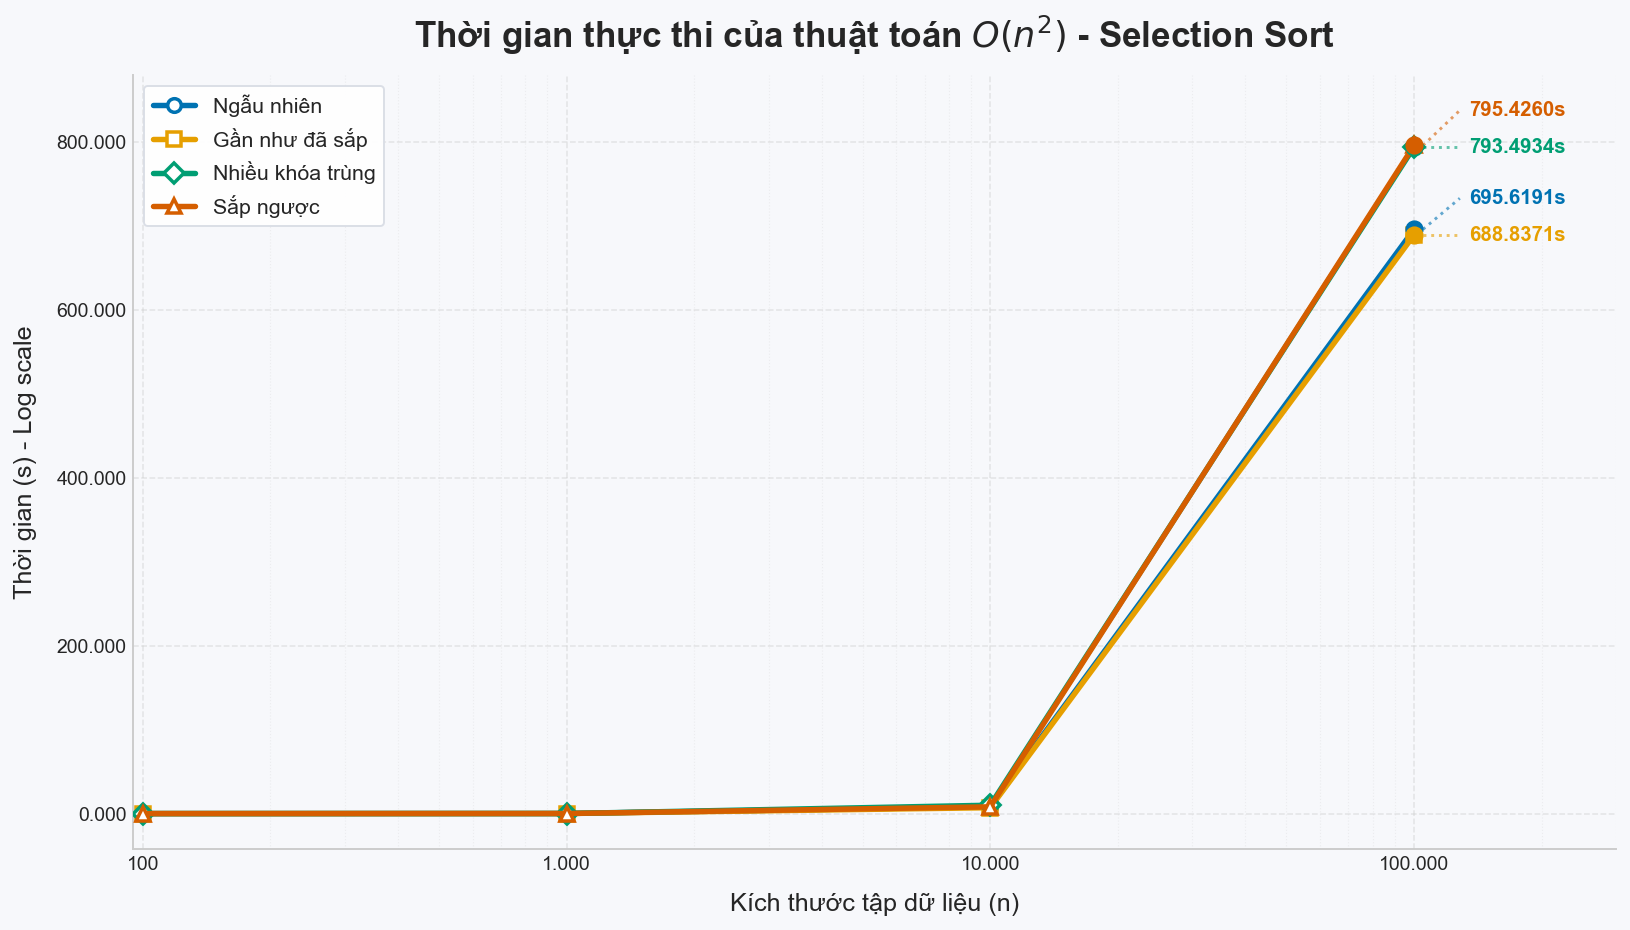

In [5]:
plot_execution_times(
    results_dict=results_selection_sort, 
    sizes=sizes, 
    datasets=datasets, 
    algo_name="$O(n^2)$ - Selection Sort"
)


#### Nhận xét biểu đồ:
##### 1. Xu hướng tổng quan
* **Tăng trưởng bậc hai rõ rệt:** Đúng như lý thuyết về độ phức tạp $O(n^2)$, khi kích thước tập dữ liệu ($n$) tăng lên, thời gian thực thi tăng theo cấp số nhân. Đường biểu diễn gần như phẳng ở giai đoạn $n = 100$ đến $n = 10.000$, nhưng sau đó bùng nổ dốc đứng khi chuyển sang $n = 100.000$.
* **Sự khác biệt ở quy mô lớn:** Ở các giá trị $n$ nhỏ (100 đến 10.000), thời gian thực thi cực thấp và gần như trùng khít nhau. Tuy nhiên, khi $n$ đạt đến **100.000**, sự phân hóa về hiệu suất giữa các loại dữ liệu bắt đầu xuất hiện rõ ràng, đặc biệt là hai nhóm tách biệt: nhóm **Ngẫu nhiên & Sắp ngược** chậm hơn hẳn so với nhóm **Gần như đã sắp & Nhiều khóa trùng**.

##### 2. So sánh các loại dữ liệu (tại $n = 100.000$)
Dựa vào các chỉ số ở cuối đường đồ thị, chúng ta thấy thứ tự thời gian thực thi từ chậm nhất đến nhanh nhất như sau:

* **Chậm nhất - Ngẫu nhiên (795.4260s):** Dữ liệu ngẫu nhiên cho kết quả chậm nhất. Điều này phù hợp với bản chất của Selection Sort — thuật toán luôn phải duyệt toàn bộ phần chưa sắp xếp để tìm phần tử nhỏ nhất, và với dữ liệu ngẫu nhiên không có quy luật nào giúp rút ngắn quá trình so sánh.
* **Sắp ngược (793.4934s):** Gần tương đương với dữ liệu ngẫu nhiên, chỉ chênh lệch khoảng 1.9 giây. Dữ liệu nghịch thế cũng buộc thuật toán thực hiện đầy đủ $\frac{n(n-1)}{2}$ lần so sánh mà không có bất kỳ lợi thế nào để bỏ qua bước duyệt.
* **Nhiều khóa trùng (695.6191s):** Nhanh hơn đáng kể so với hai trường hợp trên. Khi nhiều phần tử có cùng giá trị, số lần hoán đổi (swap) thực sự giảm thiểu, giúp tiết kiệm chi phí ghi bộ nhớ dù số lần so sánh vẫn không thay đổi.
* **Nhanh nhất - Gần như đã sắp (688.8371s):** Đây là trường hợp nhanh nhất. Khi dữ liệu gần như đã có thứ tự, số lần hoán đổi cần thực hiện giảm tối đa, dẫn đến tiết kiệm được chi phí ghi/đọc bộ nhớ dù vòng lặp so sánh vẫn diễn ra đầy đủ.

##### 3. Đặc tính kém hiệu quả của Selection Sort
* Biểu đồ cho thấy Selection Sort là một thuật toán **không ổn định về hiệu suất** khi dữ liệu lớn. Sự chênh lệch giữa trường hợp chậm nhất và nhanh nhất lên tới **106.6 giây** cho 100.000 phần tử, một biên độ dao động rất lớn.
* Dù dữ liệu đầu vào ở trạng thái nào, thuật toán vẫn **không thể thoát khỏi vòng lặp duyệt toàn bộ mảng** $O(n^2)$. Sự khác biệt giữa các loại dữ liệu chủ yếu đến từ số lần hoán đổi, chứ không phải số lần so sánh, vốn luôn cố định ở mức $\frac{n(n-1)}{2}$.

**Có thể nói:** Selection Sort có ưu điểm duy nhất là số lần hoán đổi tối thiểu ($O(n)$ lần swap), phù hợp trong các môi trường mà chi phí ghi bộ nhớ cực kỳ đắt. Tuy nhiên, với các tập dữ liệu lớn trong thực tế, đây là một thuật toán **không phù hợp** do thời gian thực thi tăng trưởng bậc hai không thể kiểm soát được.

### 5.2 Insertion Sort

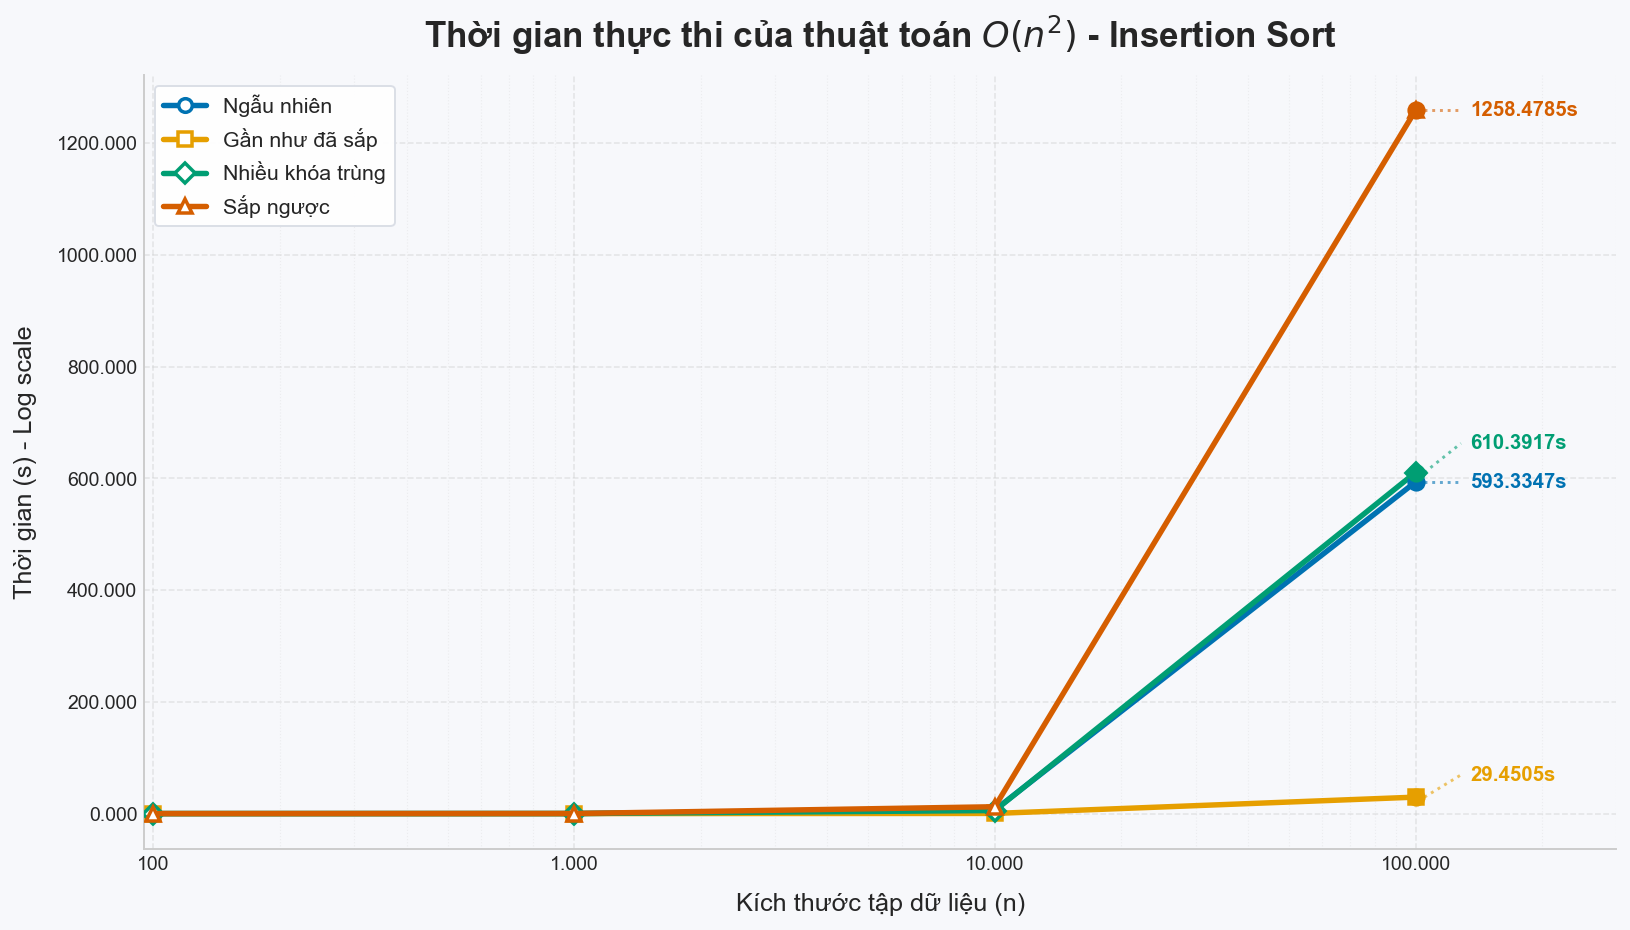

In [6]:
plot_execution_times(
    results_dict=results_insertion_sort, 
    sizes=sizes, 
    datasets=datasets, 
    algo_name="$O(n^2)$ - Insertion Sort"
)

#### Nhận xét biểu đồ:
##### 1. Xu hướng tổng quan
* **Tăng trưởng bậc hai rõ rệt:** Đúng như lý thuyết về độ phức tạp $O(n^2)$, khi kích thước tập dữ liệu ($n$) tăng lên, thời gian thực thi tăng theo cấp số nhân. Đường biểu diễn gần như phẳng ở giai đoạn $n = 100$ đến $n = 10.000$, nhưng sau đó bùng nổ dốc đứng khi chuyển sang $n = 100.000$.
* **Sự phân hóa cực đoan ở quy mô lớn:** Khác với các thuật toán khác, biểu đồ của Insertion Sort thể hiện sự phân hóa **rất đặc biệt và cực đoan**. Tại $n = 100.000$, đường **Sắp ngược** tách biệt hoàn toàn và vọt lên rất cao so với ba đường còn lại, trong khi đường **Gần như đã sắp** lại nằm sát đáy biểu đồ, tạo ra khoảng cách hiệu suất lên tới hơn **1.200 giây** giữa hai trường hợp.

##### 2. So sánh các loại dữ liệu (tại $n = 100.000$)
Dựa vào các chỉ số ở cuối đường đồ thị, chúng ta thấy thứ tự thời gian thực thi từ chậm nhất đến nhanh nhất như sau:

* **Chậm nhất - Sắp ngược (1258.4785s):** Đây là trường hợp tệ nhất (worst case) của Insertion Sort. Khi dữ liệu sắp xếp hoàn toàn ngược chiều, mỗi phần tử được chèn vào đều phải dịch chuyển qua toàn bộ các phần tử đã sắp xếp trước đó, dẫn đến đúng $\frac{n(n-1)}{2}$ lần so sánh và dịch chuyển — đây là lý do thời gian thực thi lớn gấp đôi so với trường hợp ngẫu nhiên.
* **Nhiều khóa trùng (610.3917s):** Thời gian ở mức trung bình. Dù có nhiều phần tử bằng nhau, Insertion Sort vẫn phải thực hiện nhiều phép so sánh để xác định vị trí chèn đúng, chỉ tiết kiệm được một phần nhỏ số lần dịch chuyển.
* **Ngẫu nhiên (593.3347s):** Gần tương đương với trường hợp nhiều khóa trùng, chỉ chênh lệch khoảng 17 giây. Dữ liệu ngẫu nhiên phản ánh trường hợp trung bình (average case) của thuật toán với khoảng $\frac{n(n-1)}{4}$ lần dịch chuyển.
* **Nhanh nhất - Gần như đã sắp (29.4505s):** Đây là điểm **nổi bật nhất** trong biểu đồ và cũng là ưu thế đặc trưng của Insertion Sort. Khi dữ liệu gần như đã có thứ tự, mỗi phần tử chỉ cần dịch chuyển rất ít (hoặc không cần dịch chuyển), khiến thuật toán tiệm cận $O(n)$ trong thực tế — nhanh hơn tới **hơn 42 lần** so với trường hợp sắp ngược.

##### 3. Đặc tính không ổn định của Insertion Sort
* Biểu đồ phơi bày rõ ràng sự **thiếu ổn định nghiêm trọng** về hiệu suất của Insertion Sort. Sự chênh lệch giữa trường hợp chậm nhất và nhanh nhất lên tới **1228.028 giây** — một biên độ dao động khổng lồ so với bất kỳ thuật toán nào khác.
* Điểm đặc biệt của Insertion Sort nằm ở chỗ hiệu suất của nó **phụ thuộc trực tiếp vào mức độ đã sắp xếp của dữ liệu đầu vào**. Đây vừa là điểm mạnh (với dữ liệu gần như đã sắp) vừa là điểm yếu chết người (với dữ liệu sắp ngược).

**Có thể nói:** Insertion Sort là lựa chọn **lý tưởng** khi làm việc với dữ liệu gần như đã sắp xếp hoặc các tập dữ liệu nhỏ, nhờ khả năng tiệm cận $O(n)$ trong trường hợp tốt nhất. Tuy nhiên, với dữ liệu ngẫu nhiên hoặc sắp ngược ở quy mô lớn, hiệu suất suy giảm thảm hại và hoàn toàn **không phù hợp** cho các ứng dụng thực tế yêu cầu xử lý tập dữ liệu lớn.

## 6. So sánh

Để có cái nhìn trực quan giữa 2 thuật toán thuộc nhóm $O(n^2)$, ta tiến hành so sánh chúng trên cùng 4 loại phân bố dữ liệu.

In [7]:
all_algo_results = {
    "Selection Sort": results_selection_sort,
    "Insertion Sort": results_insertion_sort,
}

sizes = [100, 1000, 10000, 100000]
datasets = ['random', 'nearly_sorted', 'many_duplicates', 'reverse_sorted']

### 6.1 Bar chart

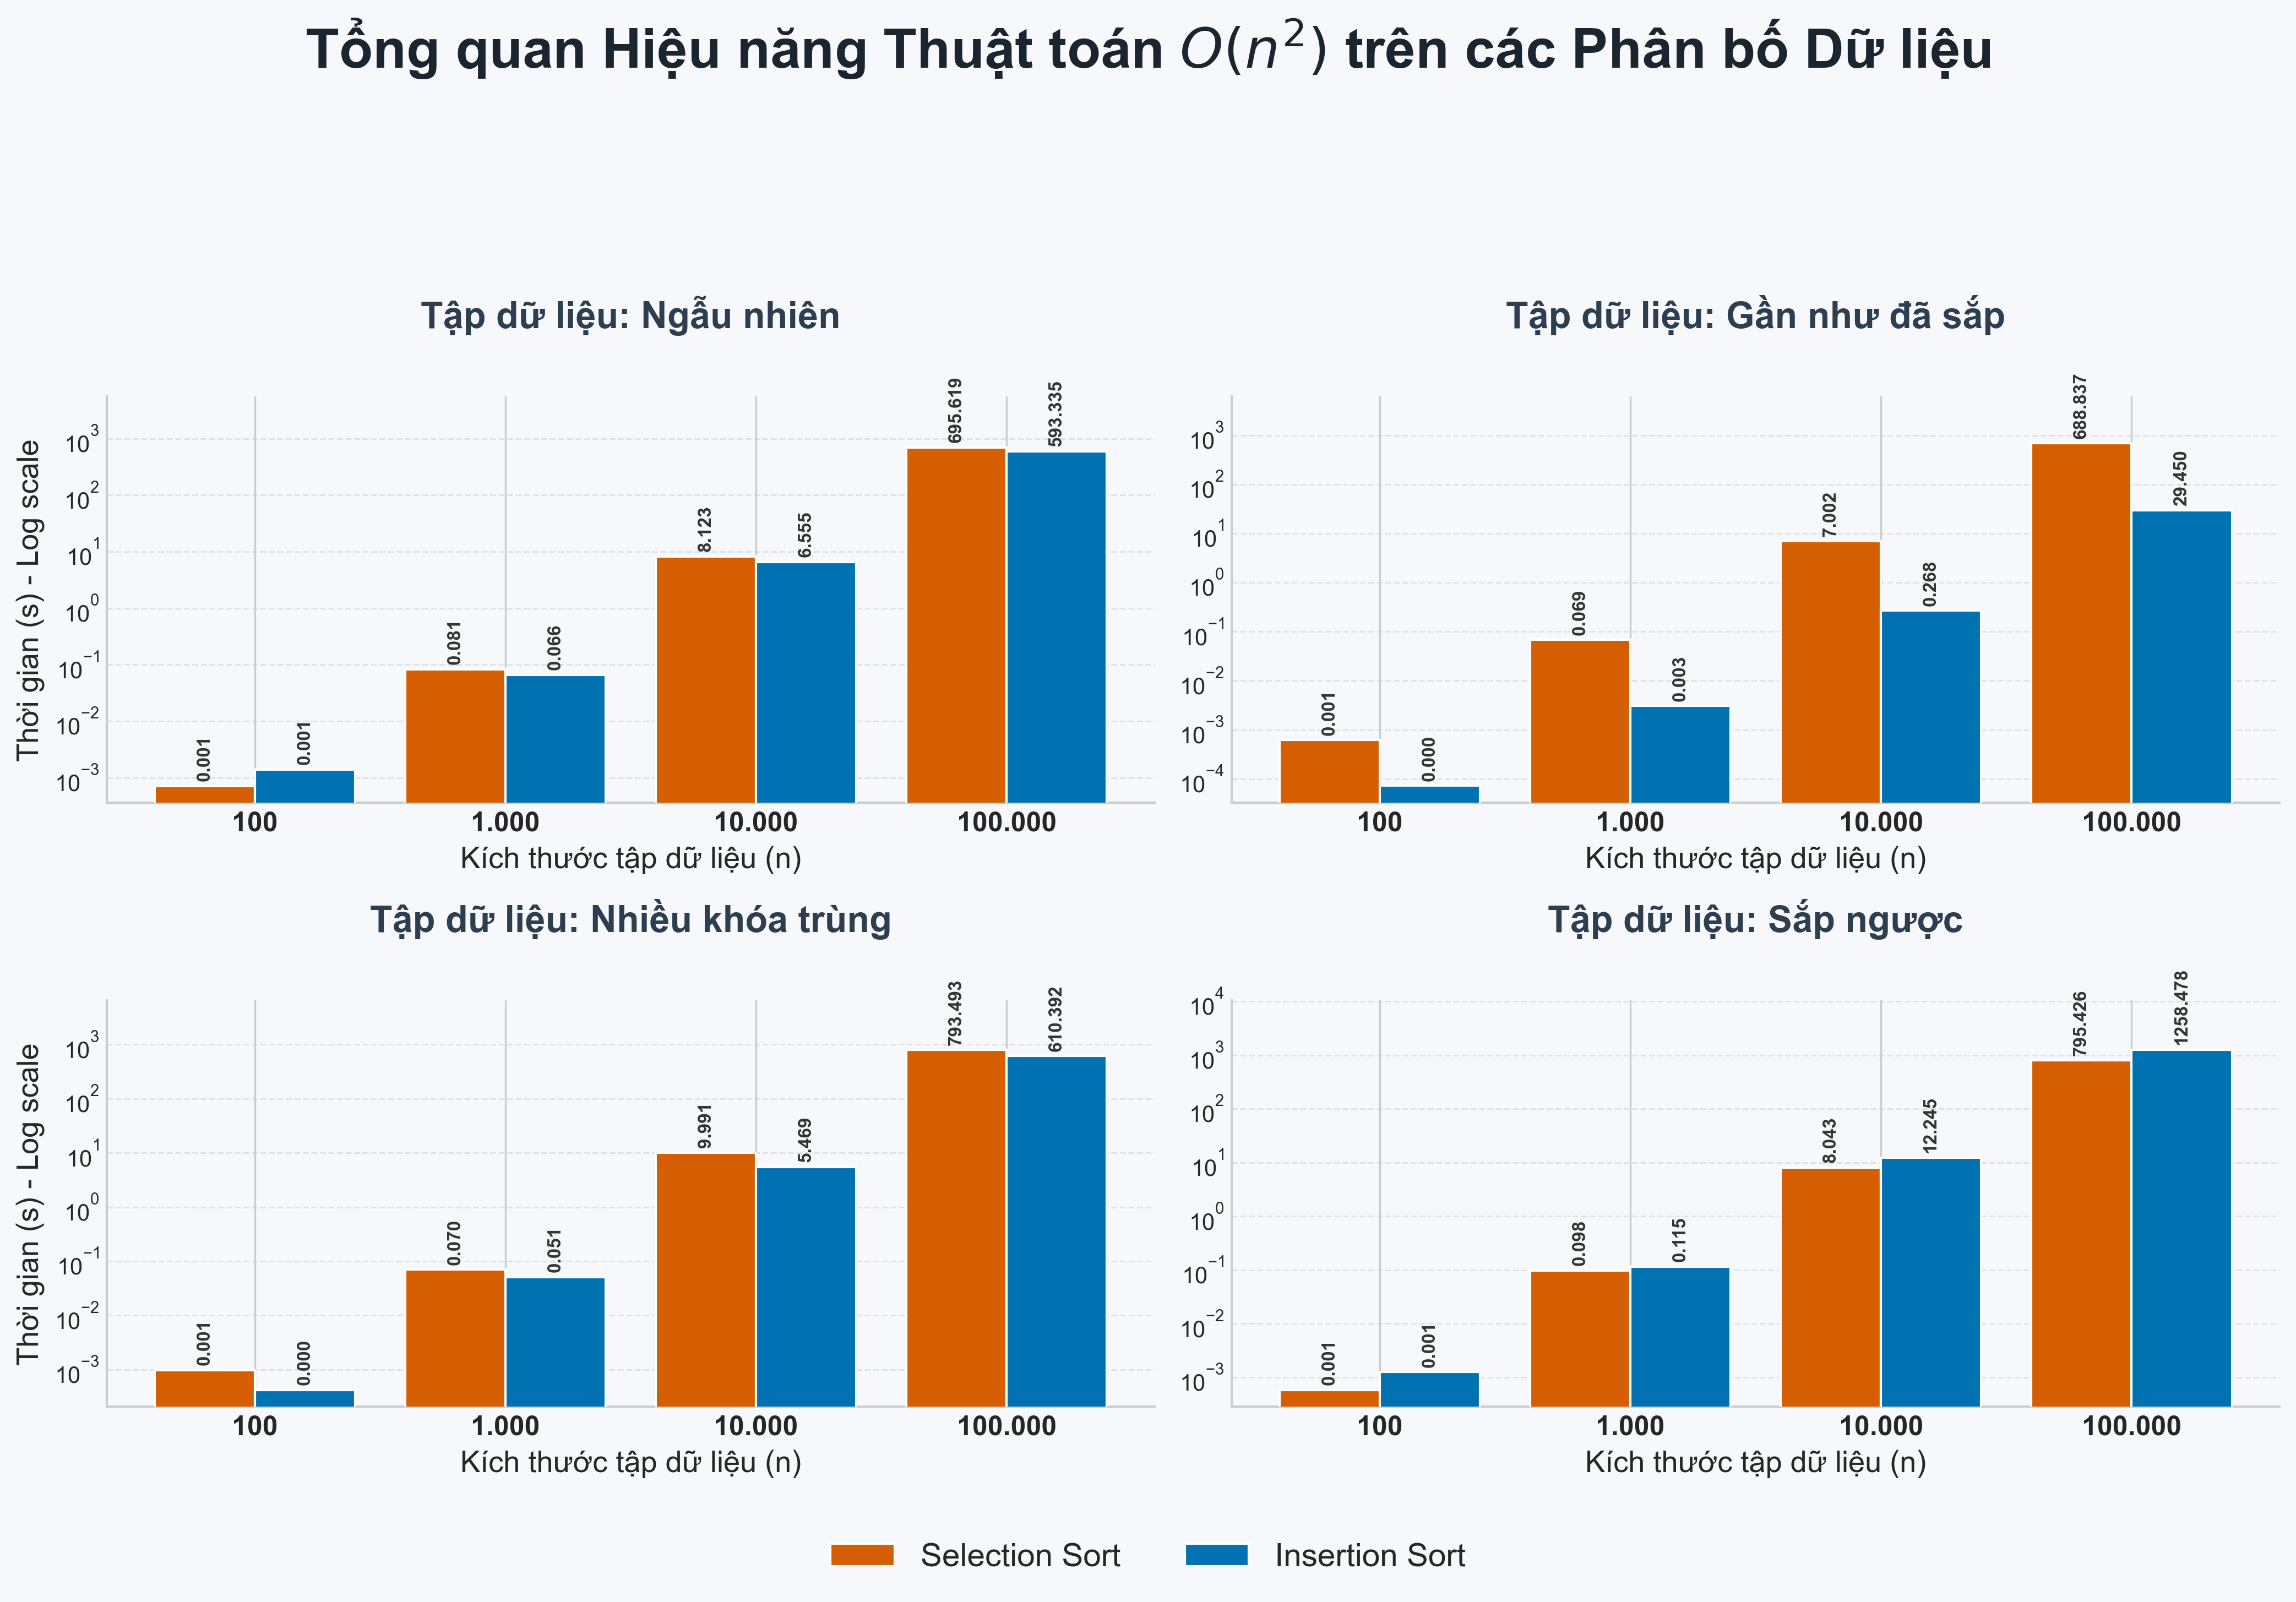

In [8]:
plot_comprehensive_barchart_grid(
    all_results=all_algo_results,
    sizes=sizes,
    datasets=datasets,
    title="Tổng quan Hiệu năng Thuật toán $O(n^2)$ trên các Phân bố Dữ liệu",
)

#### Phân tích Hiệu năng Thuật toán Sắp xếp: Selection Sort vs. Insertion Sort

Biểu đồ so sánh thời gian thực thi (giây) của hai thuật toán trên thang đo **Log Scale** với 4 loại phân bố dữ liệu khác nhau và kích thước mảng ($n$) từ 100 đến 100.000.

##### 1. Tập dữ liệu: Ngẫu nhiên (Random)
* **Quan sát:** Cả hai thuật toán đều tăng trưởng thời gian theo độ phức tạp $O(n^2)$. Tuy nhiên, có sự chênh lệch nhỏ về hằng số thời gian ở các quy mô lớn.
* **Nhận xét:** Tại $n = 100.000$, **Selection Sort** (695.619s) chậm hơn một chút so với **Insertion Sort** (593.335s).
* **Kết luận:** Với dữ liệu ngẫu nhiên, Insertion Sort có lợi thế nhờ có thể dừng sớm vòng lặp bên trong khi tìm được vị trí chèn đúng, trong khi Selection Sort luôn phải duyệt hết phần còn lại của mảng.

##### 2. Tập dữ liệu: Gần như đã sắp xếp (Nearly Sorted)
* **Quan sát:** Đây là kịch bản có sự chênh lệch **khủng khiếp** nhất giữa hai thuật toán.
* **Nhận xét:** Ở $n = 100.000$, Selection Sort mất tới **688.837s**, trong khi Insertion Sort chỉ mất **29.450s** — nhanh hơn hơn **23 lần**.
* **Giải thích:** Đây là trường hợp tốt nhất (best case) của Insertion Sort. Khi dữ liệu gần như đã có thứ tự, mỗi phần tử chỉ cần dịch chuyển rất ít hoặc không cần dịch chuyển, khiến thuật toán tiệm cận $O(n)$. Trong khi đó, Selection Sort không có cơ chế tận dụng thứ tự sẵn có và vẫn phải duyệt toàn bộ $\frac{n(n-1)}{2}$ lần so sánh.

##### 3. Tập dữ liệu: Nhiều khóa trùng (Many Duplicates)
* **Quan sát:** Cả hai thuật toán đều chịu ảnh hưởng tương đương từ dữ liệu trùng lặp, không có sự phân hóa quá lớn.
* **Nhận xét:** Tại $n = 100.000$, Selection Sort (793.493s) chậm hơn Insertion Sort (610.392s). Cả hai đều ở mức hiệu suất tương tự như trường hợp ngẫu nhiên.
* **Kết luận:** Với nhiều khóa trùng, Insertion Sort tiết kiệm được một phần số lần dịch chuyển khi gặp các phần tử bằng nhau, còn Selection Sort gần như không hưởng lợi gì từ đặc điểm này.

##### 4. Tập dữ liệu: Sắp xếp ngược (Reverse Sorted)
* **Quan sát:** Đây là kịch bản tệ nhất (worst case) của Insertion Sort, tạo ra sự đảo chiều hoàn toàn so với trường hợp gần như đã sắp.
* **Nhận xét:** Tại $n = 100.000$, **Insertion Sort** (1258.478s) chậm hơn hẳn **Selection Sort** (795.426s) — chậm hơn gần **1.6 lần**.
* **Giải thích:** Với dữ liệu sắp ngược, mỗi phần tử trong Insertion Sort phải dịch chuyển qua toàn bộ các phần tử đã sắp xếp, dẫn đến số lần dịch chuyển tối đa $\frac{n(n-1)}{2}$. Selection Sort ngược lại không bị ảnh hưởng bởi chiều sắp xếp của dữ liệu nên giữ nguyên hiệu suất.

##### Tổng kết chung

| Đặc điểm | Selection Sort (Cam) | Insertion Sort (Xanh) |
| :--- | :--- | :--- |
| **Ưu điểm** | Hiệu suất **ổn định** hơn giữa các loại dữ liệu. Số lần hoán đổi tối thiểu $O(n)$. | **Cực kỳ nhanh** với dữ liệu gần như đã sắp, tiệm cận $O(n)$. |
| **Nhược điểm** | Luôn phải duyệt đủ $\frac{n(n-1)}{2}$ lần so sánh, không tận dụng được thứ tự sẵn có. | **Bị suy biến nặng** (1258s) khi gặp dữ liệu sắp ngược — trường hợp tệ nhất. |
| **Khuyên dùng** | Khi chi phí ghi bộ nhớ (swap) đắt và dữ liệu đầu vào không có quy luật rõ ràng. | Khi dữ liệu thường xuyên ở trạng thái gần như đã sắp xếp hoặc kích thước mảng nhỏ. |

**Lưu ý:** Biểu đồ sử dụng thang đo **Log Scale** nên sự chênh lệch thực tế giữa hai thuật toán — đặc biệt ở tập dữ liệu **Gần như đã sắp** và **Sắp ngược** — lớn hơn rất nhiều so với những gì mắt thường thấy trên chiều cao cột.

### 6.2 Heatmap

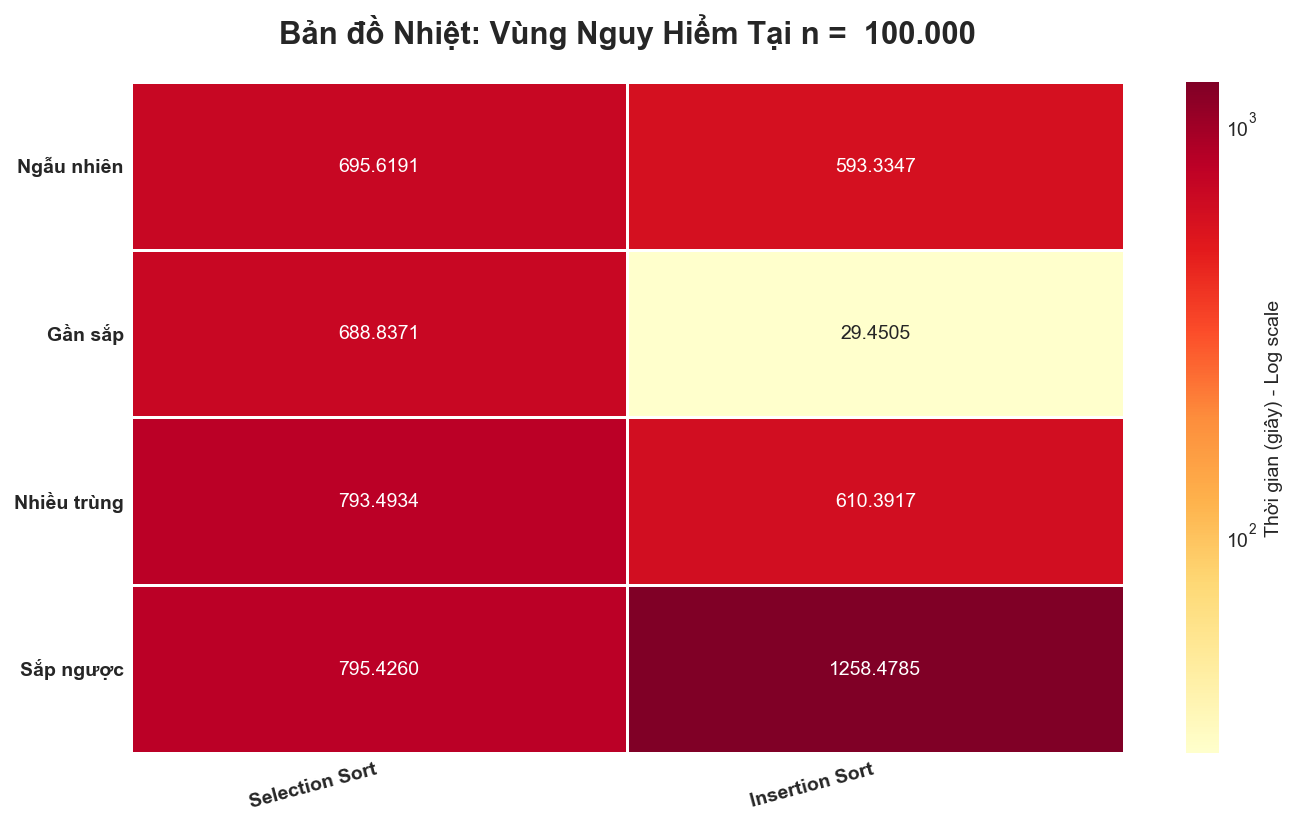

In [9]:
plot_danger_zone_heatmap(all_algo_results, 3, sizes, datasets)

### Phân tích Bản đồ Nhiệt: Hiệu năng Thuật toán tại $n = 100.000$

Biểu đồ nhiệt này trực quan hóa thời gian xử lý (giây) của **Selection Sort** và **Insertion Sort** trên thang đo Logarit, giúp xác định các "điểm nóng" về hiệu năng nơi thuật toán có dấu hiệu quá tải.

##### 1. Bảng Tổng hợp Số liệu thực tế ($n = 100.000$)

| Phân bổ dữ liệu | Selection Sort (s) | Insertion Sort (s) | Tỉ lệ (Selection/Insertion) |
| :--- | :---: | :---: | :---: |
| **Ngẫu nhiên** | 695.6191 | 593.3347 | ~1.17x (Insertion nhanh hơn) |
| **Gần sắp** | 688.8371 | **29.4505** | **~23.39x (Insertion nhanh hơn)** |
| **Nhiều trùng** | 793.4934 | 610.3917 | ~1.30x (Insertion nhanh hơn) |
| **Sắp ngược** | 795.4260 | 1258.4785 | ~1.58x (Selection nhanh hơn) |

##### 2. Phân tích Chi tiết

**Vùng Nổi bật: Gần như đã sắp (Nearly Sorted)**
* **Hiện tượng:** Đây là ô duy nhất có màu **vàng nhạt** — tương ứng với thời gian **29.4505s** của Insertion Sort. Trong khi toàn bộ các ô còn lại đều nằm trong vùng đỏ (hàng trăm giây), ô này thể hiện sự vượt trội hoàn toàn.
* **Nguyên nhân:** Đây chính là trường hợp tốt nhất (best case) của Insertion Sort. Khi dữ liệu gần như đã có thứ tự, mỗi phần tử hầu như không cần dịch chuyển, khiến thuật toán tiệm cận $O(n)$ trong thực tế.
* **Đối chiếu:** Selection Sort ở kịch bản này vẫn mất **688.8371s** (màu đỏ đều), cho thấy nó hoàn toàn không có khả năng tận dụng thứ tự sẵn có của dữ liệu.

**Vùng Nguy Hiểm: Sắp ngược (Reverse Sorted)**
* **Hiện tượng:** Đây là ô tối màu nhất trên toàn bản đồ với **1258.4785s** của Insertion Sort — đây là trường hợp tệ nhất (worst case) của thuật toán.
* **Nguyên nhân:** Với dữ liệu sắp ngược hoàn toàn, mỗi phần tử phải dịch chuyển qua toàn bộ các phần tử đã sắp xếp trước đó, đạt đúng $\frac{n(n-1)}{2}$ lần dịch chuyển — tối đa có thể xảy ra.
* **Đối chiếu:** Selection Sort (795.4260s) lại là lựa chọn tốt hơn ở kịch bản này vì nó không bị ảnh hưởng bởi chiều sắp xếp, chỉ thực hiện $O(n)$ lần hoán đổi dù số lần so sánh vẫn là $\frac{n(n-1)}{2}$.

**Vùng Ổn định: Ngẫu nhiên và Nhiều khóa trùng**
* Cả hai thuật toán đều nằm trong vùng đỏ tương đương nhau, với Insertion Sort nhanh hơn khoảng 17–30%.
* Selection Sort thể hiện sự **ổn định tương đối** — bốn ô của nó có màu sắc khá đồng đều (toàn bộ trong dải 688s–795s), không có điểm cực tốt cũng không có điểm cực xấu.

##### 3. Kết luận và Đề xuất

1. **Tính ổn định:** **Selection Sort** là thuật toán ổn định hơn về hiệu suất. Cột bên trái có màu sắc đồng nhất, không có biến động cực đoan dù dữ liệu đầu vào thay đổi — đây là điểm mạnh duy nhất đáng kể của nó.
2. **Rủi ro hệ thống:** **Insertion Sort** bộc lộ sự biến động cực đoan nhất trên toàn bản đồ — từ ô sáng nhất (29.4505s) đến ô tối nhất (1258.4785s), chênh lệch hơn **42 lần** chỉ do thay đổi phân bố dữ liệu đầu vào.
3. **Khuyến nghị kỹ thuật:**
   * Sử dụng **Insertion Sort** khi có thể đảm bảo dữ liệu đầu vào luôn ở trạng thái gần như đã sắp xếp — đây là trường hợp nó vượt trội tuyệt đối.
   * Sử dụng **Selection Sort** khi cần sự đồng nhất về thời gian xử lý và chi phí hoán đổi bộ nhớ cần được tối thiểu hóa.
   * Trong mọi tình huống xử lý dữ liệu lớn thực tế, cả hai thuật toán $O(n^2)$ này đều **không phù hợp** — thời gian hàng trăm đến hàng nghìn giây là không thể chấp nhận.

> **Ghi chú về màu sắc:** Thang đo bên phải cho thấy sự chuyển màu từ vàng (nhanh) sang đỏ đậm (chậm) theo thang Log. Ô vàng nhạt duy nhất (Insertion Sort — Gần sắp) và ô đỏ sẫm nhất (Insertion Sort — Sắp ngược) là hai cực đối lập hoàn toàn, phản ánh bản chất phụ thuộc dữ liệu đặc trưng của Insertion Sort.

### 6.3 Tỷ lệ tăng tốc của Insertion Sort so với Selection Sort

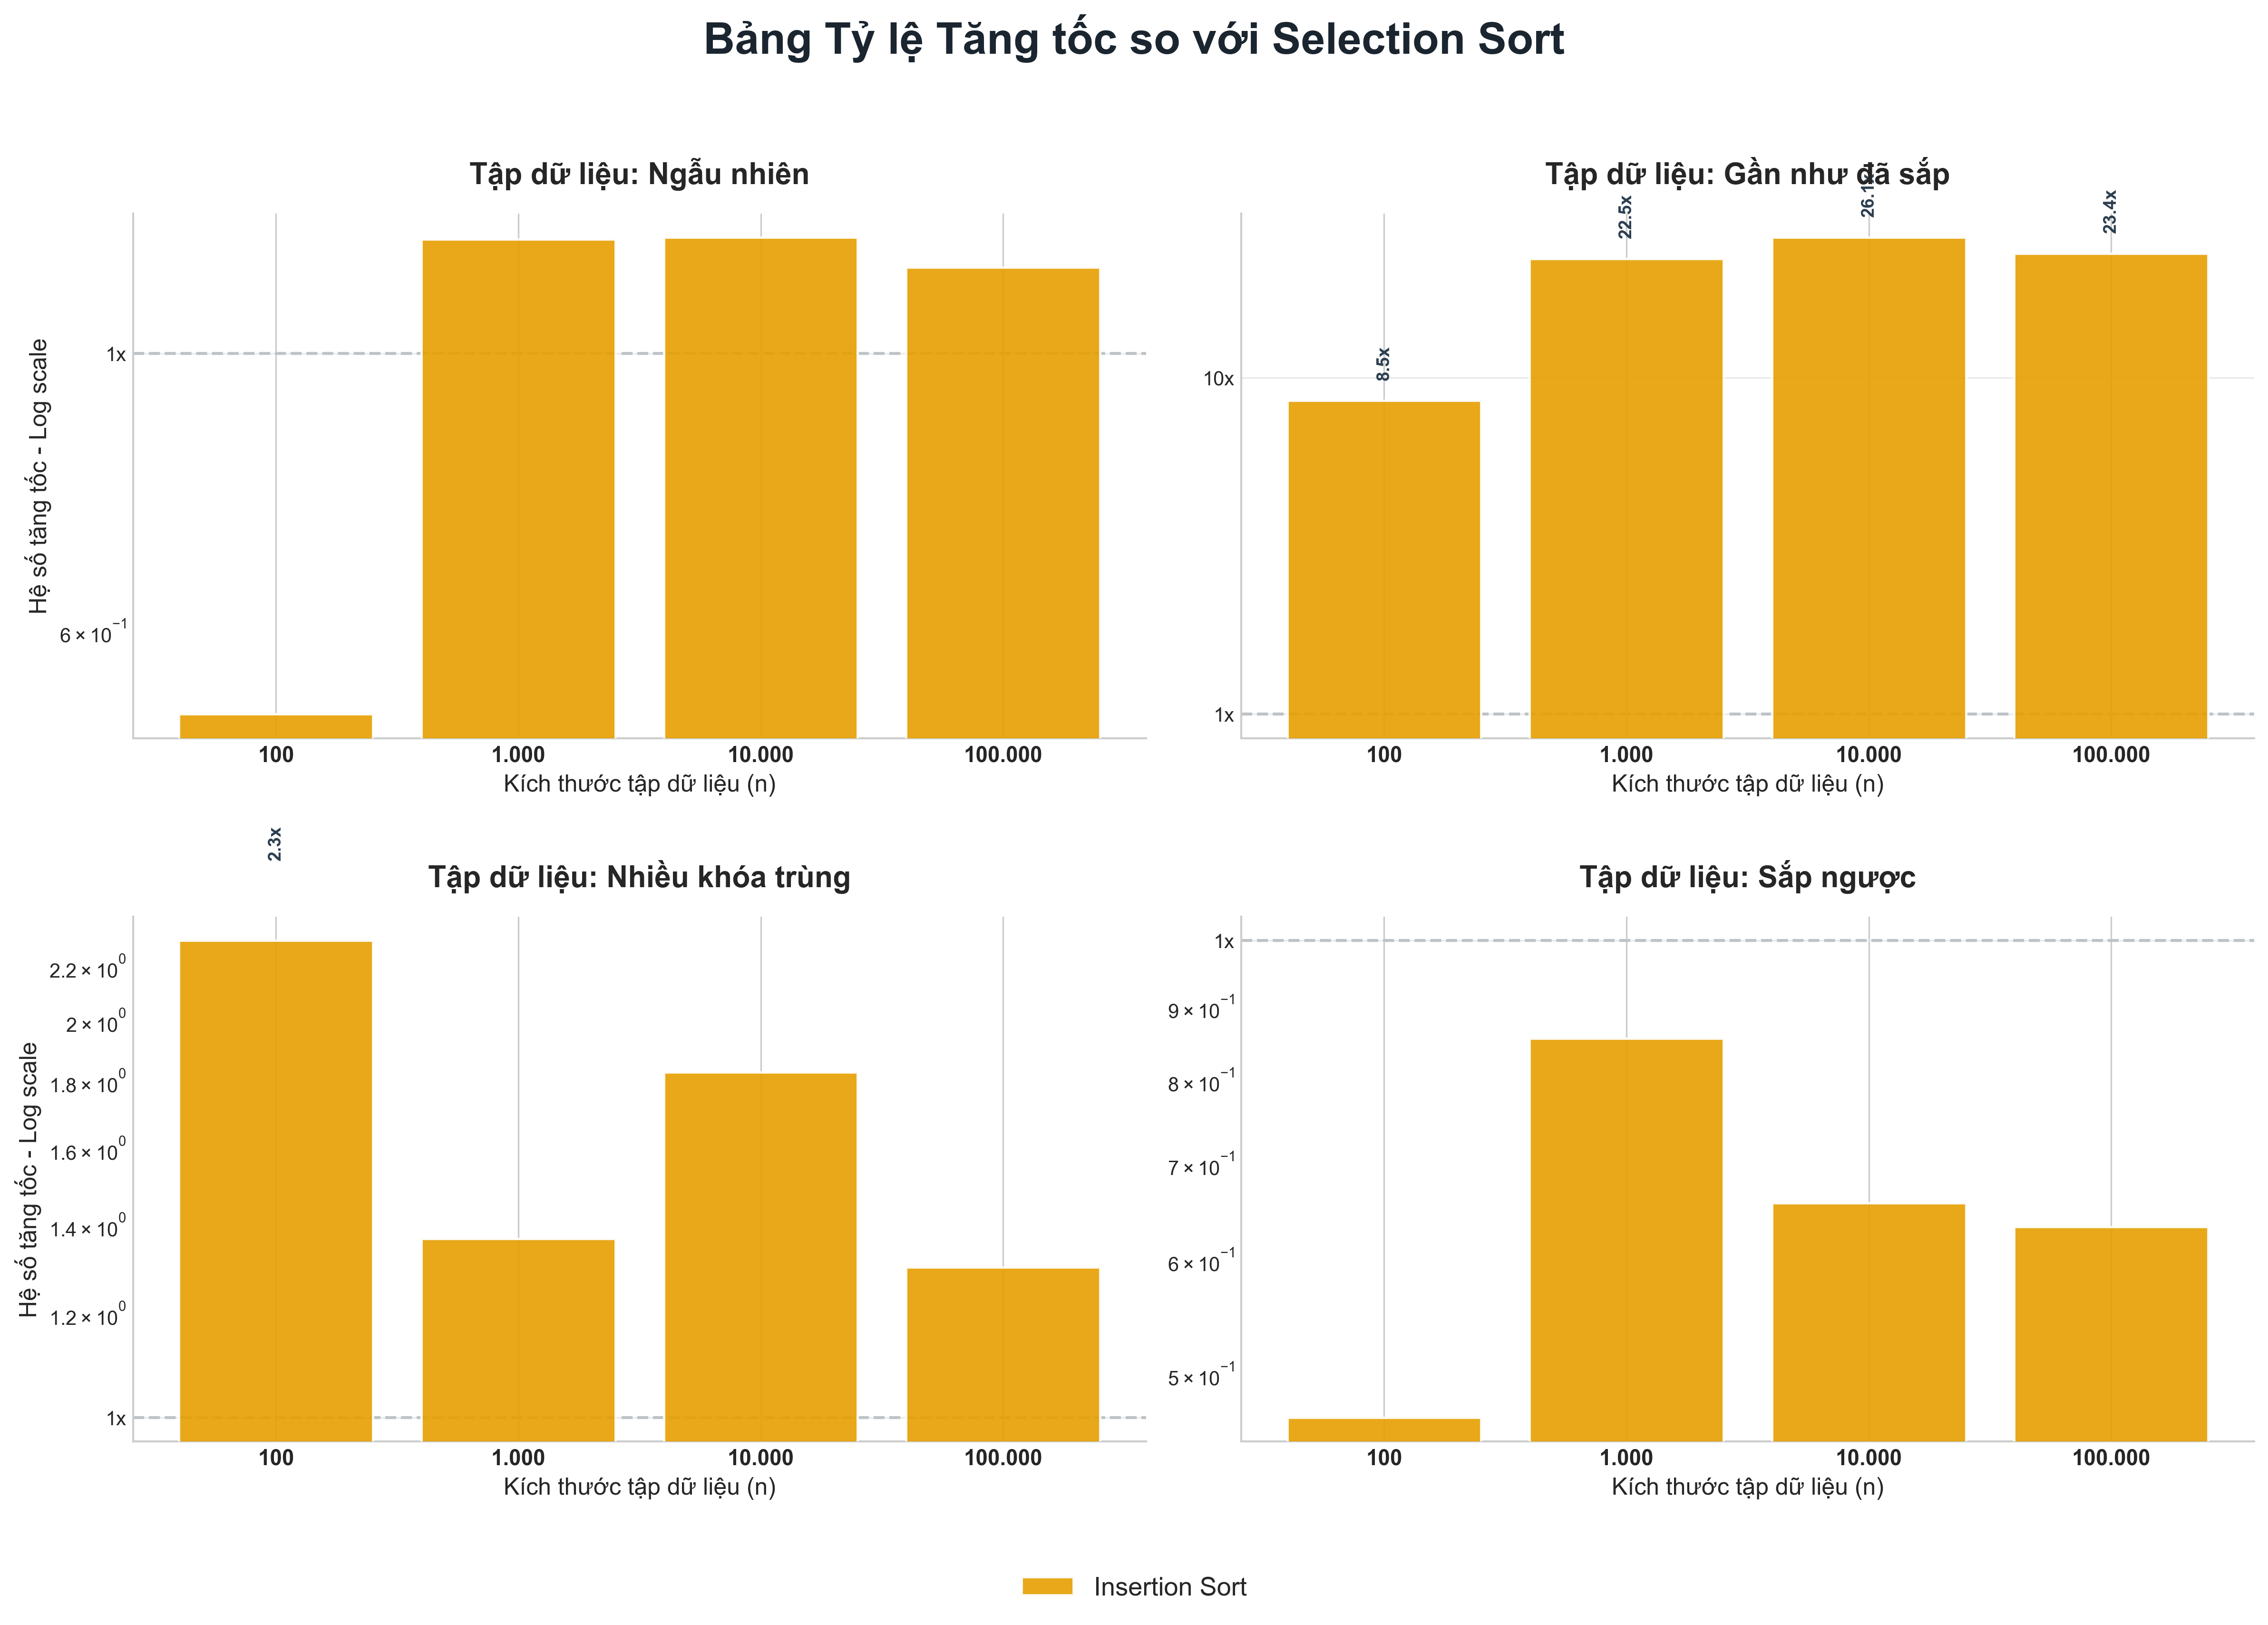

In [10]:
plot_algorithm_speedup_grid(
    all_algo_results,
    sizes,
    datasets,
    baseline_algo_name="Selection Sort",
    title="Bảng Tỷ lệ Tăng tốc so với Selection Sort",
)

### Phân tích Biểu đồ Tỷ lệ Tăng tốc: Insertion Sort so với Selection Sort

Trong biểu đồ này, đường **1x** đại diện cho hiệu năng của **Selection Sort** (mốc tham chiếu).
* Cột nằm **trên 1x**: Insertion Sort nhanh hơn Selection Sort.
* Cột nằm **dưới 1x**: Insertion Sort chậm hơn Selection Sort.

##### 1. Dữ liệu Ngẫu nhiên (Random)
* Tại $n = 100$, Insertion Sort chậm hơn Selection Sort (dưới 1x). Tuy nhiên từ $n = 1.000$ trở đi, Insertion Sort vượt lên và duy trì mức tăng tốc ổn định.
* **Kết luận:** Insertion Sort nhanh hơn Selection Sort khoảng **1.2x - 1.5x** ở các quy mô lớn với dữ liệu ngẫu nhiên, nhờ khả năng dừng sớm vòng lặp bên trong khi tìm được vị trí chèn đúng.

##### 2. Dữ liệu Gần như đã sắp xếp (Nearly Sorted)
* Đây là biểu đồ nổi bật nhất. Tỷ lệ tăng tốc leo thẳng lên mức **8.5x** tại $n = 100$, và tiếp tục duy trì ở mức **22.5x - 26x** từ $n = 1.000$ đến $n = 100.000$.
* **Kết luận:** Insertion Sort **vượt trội hoàn toàn** Selection Sort trên toàn bộ quy mô dữ liệu. Đây là trường hợp tốt nhất (best case) của Insertion Sort, tiệm cận $O(n)$, trong khi Selection Sort vẫn mắc kẹt ở $O(n^2)$.

##### 3. Dữ liệu Nhiều khóa trùng (Many Duplicates)
* Tỷ lệ tăng tốc bắt đầu cao (**2.3x** tại $n = 100$) nhưng có xu hướng **giảm dần** khi $n$ tăng lên, chỉ còn khoảng **1.3x** tại $n = 100.000$.
* **Kết luận:** Insertion Sort vẫn nhanh hơn Selection Sort nhưng lợi thế thu hẹp dần theo quy mô. Khi dữ liệu có nhiều khóa trùng, số lần dịch chuyển không giảm đủ nhiều để Insertion Sort duy trì được ưu thế lớn ở tập dữ liệu lớn.

##### 4. Dữ liệu Sắp xếp ngược (Reverse Sorted)
* Đây là biểu đồ duy nhất mà **toàn bộ các cột đều nằm dưới 1x**, dao động trong khoảng **0.45x - 0.85x**.
* **Kết luận:** Insertion Sort **chậm hơn** Selection Sort trên toàn bộ quy mô dữ liệu. Đây là trường hợp tệ nhất (worst case) của Insertion Sort — mỗi phần tử phải dịch chuyển qua toàn bộ phần đã sắp xếp, đẩy chi phí lên tối đa và khiến Selection Sort trở thành lựa chọn tốt hơn trong kịch bản này.

**Tổng kết:** Insertion Sort vượt trội Selection Sort trong hầu hết các trường hợp, đặc biệt áp đảo với dữ liệu gần như đã sắp xếp (hơn 20x). Tuy nhiên, khi gặp dữ liệu sắp ngược, vị thế hoàn toàn đảo chiều và Selection Sort lại trở nên hiệu quả hơn. Sự lựa chọn giữa hai thuật toán do đó phụ thuộc trực tiếp vào đặc điểm phân bố của dữ liệu đầu vào.

## 7. Baseline

### Phương pháp Trích xuất Đường cơ sở (Baseline) đại diện

Sau khi thu thập kết quả thực nghiệm, nhóm tổng hợp thành một "Đường cơ sở" (Baseline) duy nhất cho nhóm $O(n^2)$. Đường Baseline này đóng vai trò giá trị đại diện chuẩn mực để so sánh với các nhóm độ phức tạp khác.

**Quy trình thực hiện:**

1. **Thu thập dữ liệu ổn định:** Lấy toàn bộ kết quả thời gian thực thi của Selection Sort và Insertion Sort trên 4 kịch bản phân bố dữ liệu.
2. **Lọc dữ liệu hợp lệ:** Loại bỏ các giá trị lỗi hoặc thiếu (None) nếu có trong quá trình đo.
3. **Tính toán giá trị đại diện:** Với mỗi kích thước $n$, tính **trung bình cộng** của tất cả các trường hợp hợp lệ (2 thuật toán x 4 phân bố).

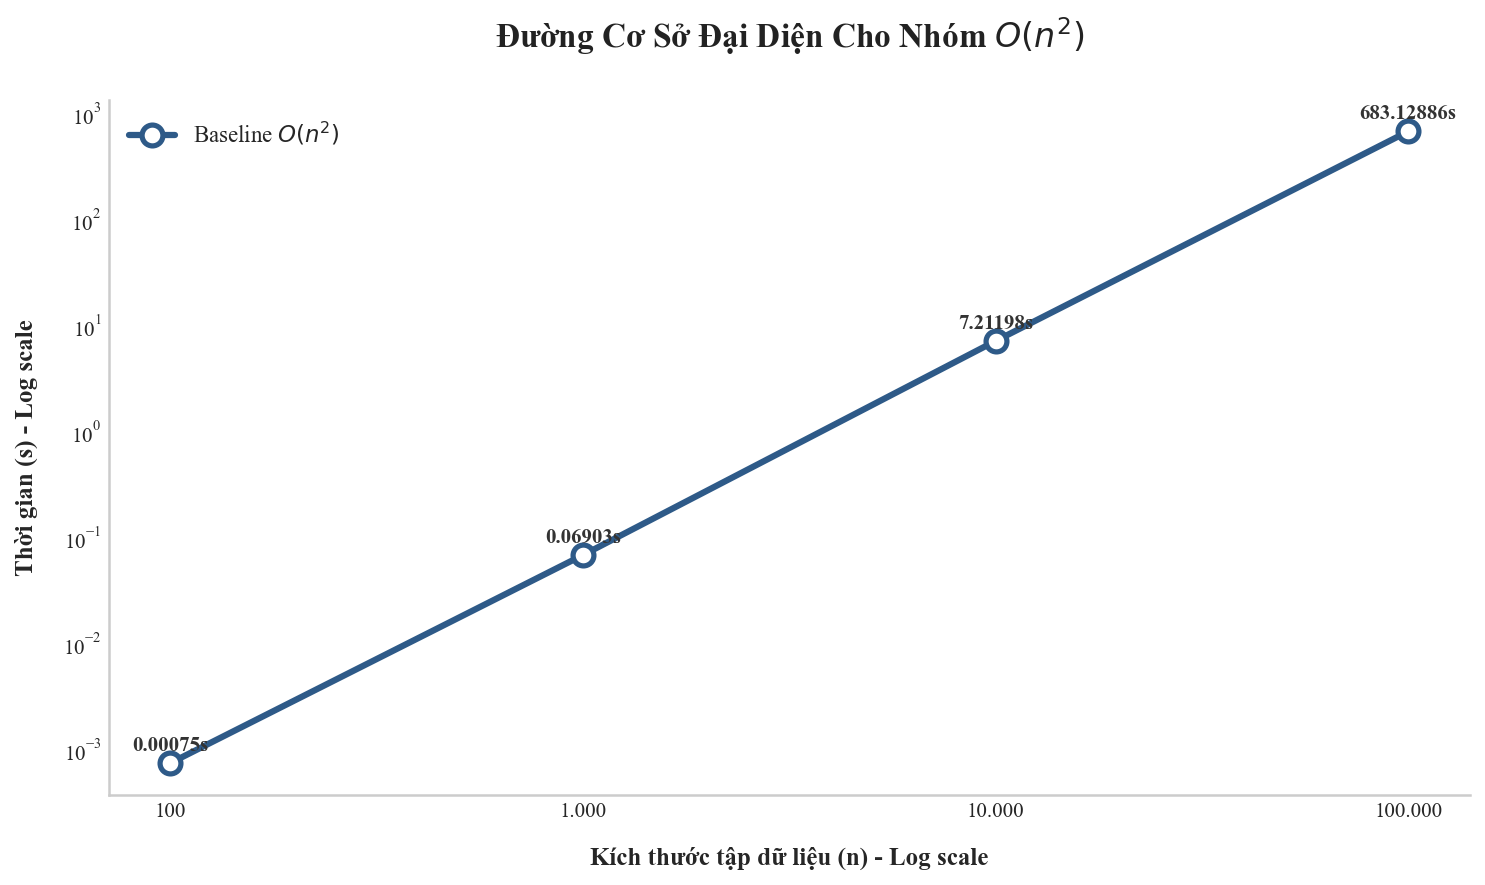

In [13]:
# Tính toán Baseline O(n^2)
baseline_results = calculate_baseline_n2(all_algo_results, sizes, datasets)

# Vẽ đường Baseline
plot_baseline_n2(sizes, baseline_results)

#### Nhận xét biểu đồ: Đường Cơ Sở Đại Diện Cho Nhóm $O(n^2)$

Biểu đồ này đóng vai trò là "thước đo chuẩn" (baseline) để so sánh hiệu năng thực tế của các thuật toán cùng nhóm như Selection Sort và Insertion Sort.

##### 1. Xu hướng tăng trưởng trên thang đo Log-Log
* **Tính tuyến tính hóa:** Trên biểu đồ có cả hai trục đều sử dụng thang đo Logarit (**Log scale**), đường biểu diễn $O(n^2)$ tạo thành một **đường thẳng hoàn hảo**. Đây là đặc trưng toán học của hàm bậc hai trên thang Log-Log — độ dốc của đường thẳng chính xác bằng **2**, phản ánh đúng số mũ trong $O(n^2)$.
* **Tốc độ tăng trưởng:** Khi kích thước dữ liệu $n$ tăng gấp **10 lần**, thời gian thực thi tăng gấp xấp xỉ **100 lần** — đây là hệ quả trực tiếp của bản chất bậc hai, khác hoàn toàn với nhóm $O(n \log n)$ chỉ tăng khoảng 10–13 lần trong cùng điều kiện.

##### 2. Các chỉ số điểm mốc quan trọng

| Kích thước $n$ | Thời gian (s) | Tỉ lệ tăng thời gian | Tỉ lệ tăng $n$ |
| :---: | :---: | :---: | :---: |
| 100 | 0.00075 | — | — |
| 1.000 | 0.06903 | ~**92x** | 10x |
| 10.000 | 7.21198 | ~**104x** | 10x |
| 100.000 | 683.12886 | ~**94x** | 10x |

* **Nhận xét:** Mỗi lần $n$ tăng 10 lần, thời gian thực thi tăng xấp xỉ **100 lần** — hoàn toàn khớp với lý thuyết $O(n^2)$. Sai số nhỏ (92x–104x) là do các yếu tố thực tế như cache, overhead hệ thống, không ảnh hưởng đến kết luận tổng quan.

##### 3. Ý nghĩa của Đường Cơ Sở (Baseline)
* **Điểm tham chiếu:** Đường Baseline $O(n^2)$ là mốc lý thuyết để đánh giá hiệu năng thực tế của Selection Sort và Insertion Sort. Khi đặt các đường thực tế lên cùng biểu đồ, ta có thể quan sát liệu một thuật toán đang bám sát hay lệch khỏi đường cơ sở — từ đó xác định được hằng số ẩn trong độ phức tạp thực tế của từng thuật toán.
* **Cảnh báo về quy mô:** Với **683s** (~11 phút) chỉ để xử lý 100.000 phần tử, đường Baseline này là lời cảnh báo rõ ràng rằng nhóm thuật toán $O(n^2)$ **không thể mở rộng** (not scalable) cho các bài toán thực tế có dữ liệu lớn.

**Kết luận:** Đường cơ sở khẳng định ngưỡng **683 giây** là cột mốc hiệu năng tiêu chuẩn cho 100.000 phần tử đối với các thuật toán thuộc nhóm $O(n^2)$ — cao hơn hơn **1.000 lần** so với ngưỡng tương ứng của nhóm $O(n \log n)$, minh họa rõ ràng sự vượt trội về lý thuyết lẫn thực tế của các thuật toán sắp xếp hiệu quả hơn.

#### Ghi nhận kết quả

In [15]:
dir_path = "../results"
os.makedirs(dir_path, exist_ok=True)
with open(f"{dir_path}/baseline_O_n2.json", "w") as f:
    json.dump(baseline_results, f)

print("Đã xuất dữ liệu baseline O(n^2) thành công!")

Đã xuất dữ liệu baseline O(n^2) thành công!
